<a href="https://colab.research.google.com/github/zry3fr/undergrad_ml_assignments/blob/main/COMPLETE_04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.
1. Adding a penalty to mean squared error prevents the model from using large coefficients. Large coefficients typically correspond to an overfitting and complex model. By penalizing the "size" of the model parameters, the model is forced to stay simpler and focus on the most important patterns instead of incorporating every small fluctuation. This allows the model perform better on new and unseen data.
2. Regularization explores the bias-variance trade-off by allowing you to control the model's complexity through a penalty parameter. For example, with having a large penalty, the model has a high bias but low variance, making it underfitting (and vise versa). By adjusting the penalty strength, you can find a balance between underfitting and overfitting where the model generalizes best to new and unseen data.
3. LASSO regression can shrink coefficients by a constant amount or all the way to zero, effectively removing variables. Ridge regression can shrink coefficients toward zero, but does not make them exactly zero. Therefore, it keeps all variables just with smaller effects. LASSO regression is better when only a few variables are important, because it creates a simpler model by selecting features. Ridge regression is better when many variables have small, spread out effects. Ridge regression typically performs better, while LASSO regression provides more interpretable results.
4. We usually standardize variables in regularized regression, which means subtracting the mean and dividing by the standard deviation. This is because regularization penalities depend on the size of coefficients. If variables are on different scales, the penalty would disproportionately affect some variables more than others. Scaling makes the penalty apply equally across all predictors.
5. The penalty a is typically selected using cross-validation. This is done by trying different values of the penalty and picking the one that gives the lowest prediction error on validation data. The purpose is to find the optimal balance between bias and variance. It helps ensure the model performs well on new and unseen data.
6. No, we do not include the penalty term in evaluating the cross validated MSE. This is because we care about how well the model predicts new data, not how small the coefficients are. The penalty is only used during training to control model complexity. Prediction error should be measured using just the regular MSE.

**Q2.** This is a case study on regularization.



In [ ]:
! git clone https://github.com/zry3fr/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 33 (delta 10), reused 4 (delta 4), pack-reused 19 (from 1)
Receiving objects: 100% (33/33), 42.65 KiB | 450.00 KiB/s, done.
Resolving deltas: 100% (11/11), done.
Download complete
Extracting data files...
Data extracted


1.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV

In [ ]:
cars = pd.read_csv('/content/data/cars_hw.csv')
cars.head(10)

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000
5,6,Hyundai,2016,red,hatchback,52261,1st,5,petrol,5-Speed,Manual,604000
6,7,Honda,2012,grey,hatchback,28108,2nd,5,petrol,5-Speed,Manual,316000
7,8,Tata,2019,grey,suv,92603,1st,5,diesel,6-Speed,Automatic,1419000
8,9,Hyundai,2021,blue,hatchback,16304,1st,5,petrol,5-Speed,Manual,710000
9,10,Renault,2019,bronze,hatchback,26350,2nd,5,petrol,5-Speed,Manual,392000


In [ ]:
current_year = 2026
cars['Age'] = current_year - cars['Make_Year']

In [ ]:
X = cars[['Mileage_Run', 'Age']]
y = cars['Price']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

2.

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
lin_coefs = pd.Series(lin_reg.coef_, index=feature_names)

interaction_sign = lin_coefs['Mileage_Run Age']
interaction_sign

np.float64(-1671212.3563918793)

The interaction between Mileage_Run and Age has a negative sign. This means that when both mileage and age increase together, the price of the car decreases more sharply. This suggests that older cars with high mileage experience a stronger drop in value compared to cars where only one of these factors is high.

3.

In [ ]:
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=100000)
lasso_cv.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

4.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
mse_path = lasso_cv.mse_path_.mean(axis=1)

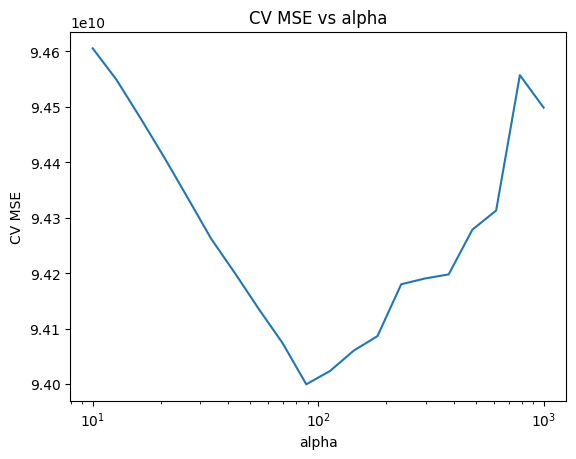

In [ ]:
plt.figure()
plt.plot(lasso_cv.alphas_, mse_path)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('CV MSE')
plt.title('CV MSE vs alpha')
plt.show()

5.

In [ ]:
coefs = []
for a in alphas:
    from sklearn.linear_model import Lasso
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

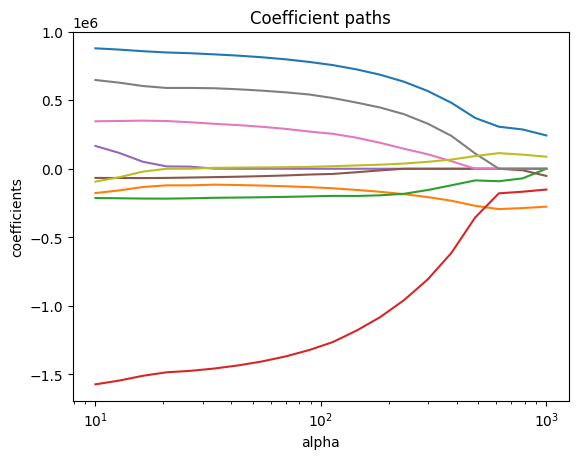

In [ ]:
plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title('Coefficient paths')
plt.show()

6.

In [ ]:
selected = lasso_coefs[lasso_coefs != 0]
prop_zero = (lasso_coefs == 0).mean()

interaction_sign, selected.index.tolist(), prop_zero

(np.float64(-1671212.3563918793),
 ['Mileage_Run',
  'Age',
  'Mileage_Run^2',
  'Mileage_Run Age',
  'Mileage_Run^3',
  'Mileage_Run^2 Age',
  'Mileage_Run Age^2',
  'Age^3'],
 np.float64(0.1111111111111111))

LASSO keeps almost all of the features, including mileage, age, and most of the polynomial terms. It only removes a small number of features. About 11% of the coefficients are set to zero, which means only a few features are dropped from the model while most are still used.

7.

In [ ]:
comparison = pd.DataFrame({
    "Linear": lin_coefs,
    "LASSO": lasso_coefs
})

print(comparison)

                         Linear         LASSO
Mileage_Run        9.117748e+05  7.790762e+05
Age               -2.481722e+05 -1.339534e+05
Mileage_Run^2     -2.072926e+05 -2.015634e+05
Mileage_Run Age   -1.671212e+06 -1.322419e+06
Age^2              3.505507e+05  0.000000e+00
Mileage_Run^3     -6.514490e+04 -4.240952e+04
Mileage_Run^2 Age  3.388195e+05  2.715062e+05
Mileage_Run Age^2  7.167816e+05  5.415432e+05
Age^3             -2.100379e+05  1.374220e+04


In [ ]:
magnitude_change = comparison[
    comparison["LASSO"].abs() > comparison["Linear"].abs()
]

print("Coefficients that increased in magnitude:")
print(magnitude_change)

Coefficients that increased in magnitude:
Empty DataFrame
Columns: [Linear, LASSO]
Index: []


In [ ]:
sign_change = comparison[
    np.sign(comparison["LASSO"]) != np.sign(comparison["Linear"])
]

print("Sign changes:")
print(sign_change)

Sign changes:
              Linear        LASSO
Age^2  350550.719877      0.00000
Age^3 -210037.887636  13742.20318


When comparing linear regression to the optimally regularized LASSO model, most coefficients decrease in magnitude. This shows that LASSO shrinks parameter values to reduce model complexity. No coefficients increase in magnitude, which is expected because LASSO applies a penalty that discourages large values rather than amplifying them.

There are also sign changes for some features. Specificially, Age^3 changes from a large negative value in linear regression to a small positive value in LASSO. Age^2 is reduced to zero, removing its effect. These changes occur because LASSO removes and/or shrinks correlated polynomial terms, which can shift how remaining features are weighted.

**Q3.** This is a case study on regularization.



1.

In [ ]:
heart = pd.read_csv("/content/data/heart_failure_clinical_records_dataset.csv")
heart.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


In [ ]:
cont = heart[['age', 'ejection_fraction', 'serum_creatinine']]
y = heart['DEATH_EVENT']

poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(cont)

cont_names = poly_cont.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])

scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

In [ ]:
cat = heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]

poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(cat)

cat_names = poly_cat.get_feature_names_out(cat.columns)

In [ ]:
X = np.hstack([X_cont_scaled, X_cat])
feature_names = list(cont_names) + list(cat_names)

2.

In [ ]:
lin = LinearRegression()
lin.fit(X, y)

lin_coefs = pd.Series(lin.coef_, index=feature_names)
lin_coefs

,0
age,1.539156
ejection_fraction,-2.192494
serum_creatinine,-0.853588
age^2,-3.678654
age ejection_fraction,-0.600918
age serum_creatinine,1.841563
ejection_fraction^2,3.430976
ejection_fraction serum_creatinine,2.673394
serum_creatinine^2,-2.647041
age^3,1.993135


Several of the coefficient signs appear counterintuitive at first, especially for variables like age and ejection_fraction where the main effect and the squared term have opposite signs. This might seem contradictory because we might expect each variable to have a consistent positive or negative relationship with the outcome. However, this happens because the model includes higher-order polynomial terms and interactions, meaning the effect of one variable depends on the level of another. These additional terms allow the relationship between predictors and death risk to be non-linear and more flexible. This captures curves and combined effects rather than forcing a single constant effect. As a result, the mixed signs are not true contradictions but instead reflect more complex relationships in the data.

3.

In [ ]:
alphas = np.logspace(-3, 3, 50)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=20000)
lasso_cv.fit(X, y)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)

4.

In [ ]:
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
mse_mean

array([0.22838432, 0.22838432, 0.22838432, 0.22838432, 0.22838432,
       0.22838432, 0.22838432, 0.22838432, 0.22838432, 0.22838432,
       0.22838432, 0.22838432, 0.22838432, 0.22838432, 0.22838432,
       0.22838432, 0.22838432, 0.22838432, 0.22838432, 0.22838432,
       0.22838432, 0.22838432, 0.22838432, 0.22838432, 0.22838432,
       0.22838432, 0.22838432, 0.22838432, 0.22838432, 0.22838432,
       0.22838432, 0.22825636, 0.21965693, 0.20685498, 0.19875185,
       0.192724  , 0.18891969, 0.186099  , 0.18384232, 0.1823866 ,
       0.17846005, 0.17667811, 0.17653989, 0.17710165, 0.17770561,
       0.17900173, 0.18110842, 0.18264102, 0.18623527, 0.18805322])

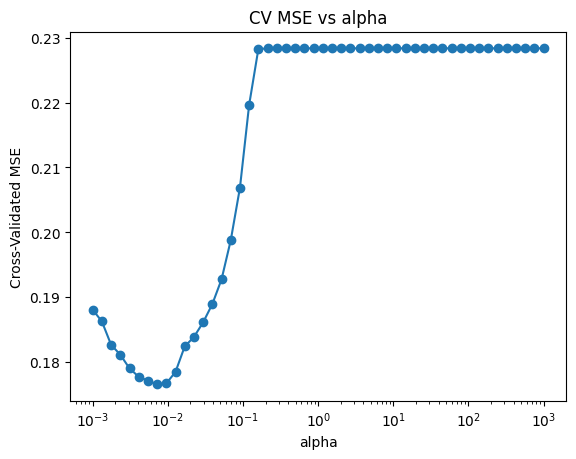

In [ ]:
plt.figure()
plt.plot(lasso_cv.alphas_, mse_mean, marker='o')
plt.xscale('log')
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs alpha")
plt.show()

5.

In [ ]:
coefs = []

for a in alphas:
    l = Lasso(alpha=a, max_iter=20000)
    l.fit(X, y)
    coefs.append(l.coef_)

coefs = np.array(coefs)

In [ ]:
sorted_idx = np.argsort(alphas)
alphas_sorted = np.array(alphas)[sorted_idx]
coefs_sorted = coefs[sorted_idx]

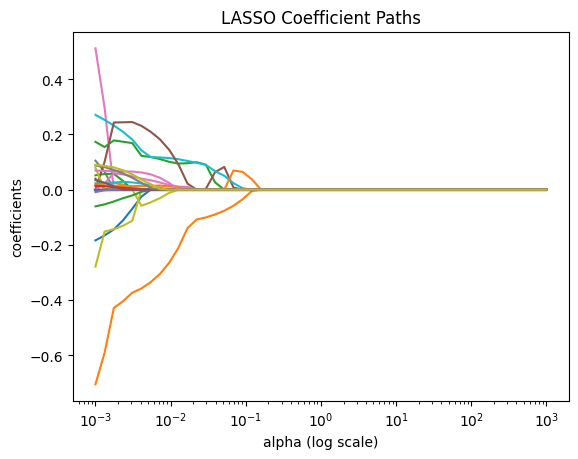

In [ ]:
plt.figure()

for i in range(coefs_sorted.shape[1]):
    plt.plot(alphas_sorted, coefs_sorted[:, i])

plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("coefficients")
plt.title("LASSO Coefficient Paths")
plt.show()

6.

In [ ]:
selected = lasso_coefs[lasso_coefs != 0]
prop_zero = (lasso_coefs == 0).mean()

interaction_sign, selected.index.tolist(), prop_zero

(np.float64(-1671212.3563918793),
 ['ejection_fraction',
  'serum_creatinine',
  'age^3',
  'ejection_fraction^3',
  'ejection_fraction^2 serum_creatinine',
  'serum_creatinine^3',
  'anaemia',
  'high_blood_pressure',
  'diabetes high_blood_pressure',
  'high_blood_pressure smoking'],
 np.float64(0.6551724137931034))

LASSO selected features include ejection fraction, serum creatinine, several higher-order polynomial terms, along with a few interaction terms involving the categorical variables. Approximately 65.5% of the coefficients are set to zero, indicating that LASSO removes a large portion of the original feature space and keeps only the most predictive variables.

In [ ]:
comparison = pd.DataFrame({
    "Linear": lin_coefs,
    "LASSO": lasso_coefs
})

print(comparison)

                                          Linear     LASSO
age                                     1.539156 -0.000000
ejection_fraction                      -2.192494 -0.305356
serum_creatinine                       -0.853588  0.110925
age^2                                  -3.678654  0.000000
age ejection_fraction                  -0.600918 -0.000000
age serum_creatinine                    1.841563  0.000000
ejection_fraction^2                     3.430976  0.000000
ejection_fraction serum_creatinine      2.673394  0.000000
serum_creatinine^2                     -2.647041 -0.000000
age^3                                   1.993135  0.116798
age^2 ejection_fraction                 0.908026  0.000000
age^2 serum_creatinine                 -0.697522  0.000000
age ejection_fraction^2                -0.081206  0.000000
age ejection_fraction serum_creatinine -1.577665  0.000000
age serum_creatinine^2                  1.284099 -0.000000
ejection_fraction^3                    -1.250341  0.1824

In [ ]:
magnitude_change = comparison[
    comparison["LASSO"].abs() > comparison["Linear"].abs()
]

print("Coefficients that increased in magnitude:")
print(magnitude_change)

Coefficients that increased in magnitude:
                       Linear     LASSO
high_blood_pressure -0.007934  0.014996


In [ ]:
sign_change = comparison[
    np.sign(comparison["LASSO"]) != np.sign(comparison["Linear"])
]

print("Sign changes:")
print(sign_change)

Sign changes:
                                          Linear     LASSO
age                                     1.539156 -0.000000
serum_creatinine                       -0.853588  0.110925
age^2                                  -3.678654  0.000000
age ejection_fraction                  -0.600918 -0.000000
age serum_creatinine                    1.841563  0.000000
ejection_fraction^2                     3.430976  0.000000
ejection_fraction serum_creatinine      2.673394  0.000000
serum_creatinine^2                     -2.647041 -0.000000
age^2 ejection_fraction                 0.908026  0.000000
age^2 serum_creatinine                 -0.697522  0.000000
age ejection_fraction^2                -0.081206  0.000000
age ejection_fraction serum_creatinine -1.577665  0.000000
age serum_creatinine^2                  1.284099 -0.000000
ejection_fraction^3                    -1.250341  0.182485
ejection_fraction^2 serum_creatinine   -1.270043  0.026247
ejection_fraction serum_creatinine^2    1.

Compared to linear regression, the LASSO model generally shrinks coefficients toward zero and sets many of them exactly to zero. Most coefficients decrease in magnitude and only one feature (high_blood_pressure) shows a slight increase in absolute value under LASSO.

Several coefficients change sign or become effectively zero in LASSO compared to linear regression, such as serum_creatinine and age-related interaction terms. However, many of these sign changes reflect the fact that LASSO is shrinking coefficients to zero rather than truly reversing strong effects. Therefore, the model is effectively removing unstable predictors rather than flipping their influence.

From a bias–variance trade-off perspective, linear regression has low bias but high variance, meaning it is overfitting. LASSO introduces bias by shrinking coefficients, but it reduces variance significantly. Therefore, LASSO produces a simpler model that generalizes better. This trade-off explains why LASSO coefficients are smaller and more stable.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.



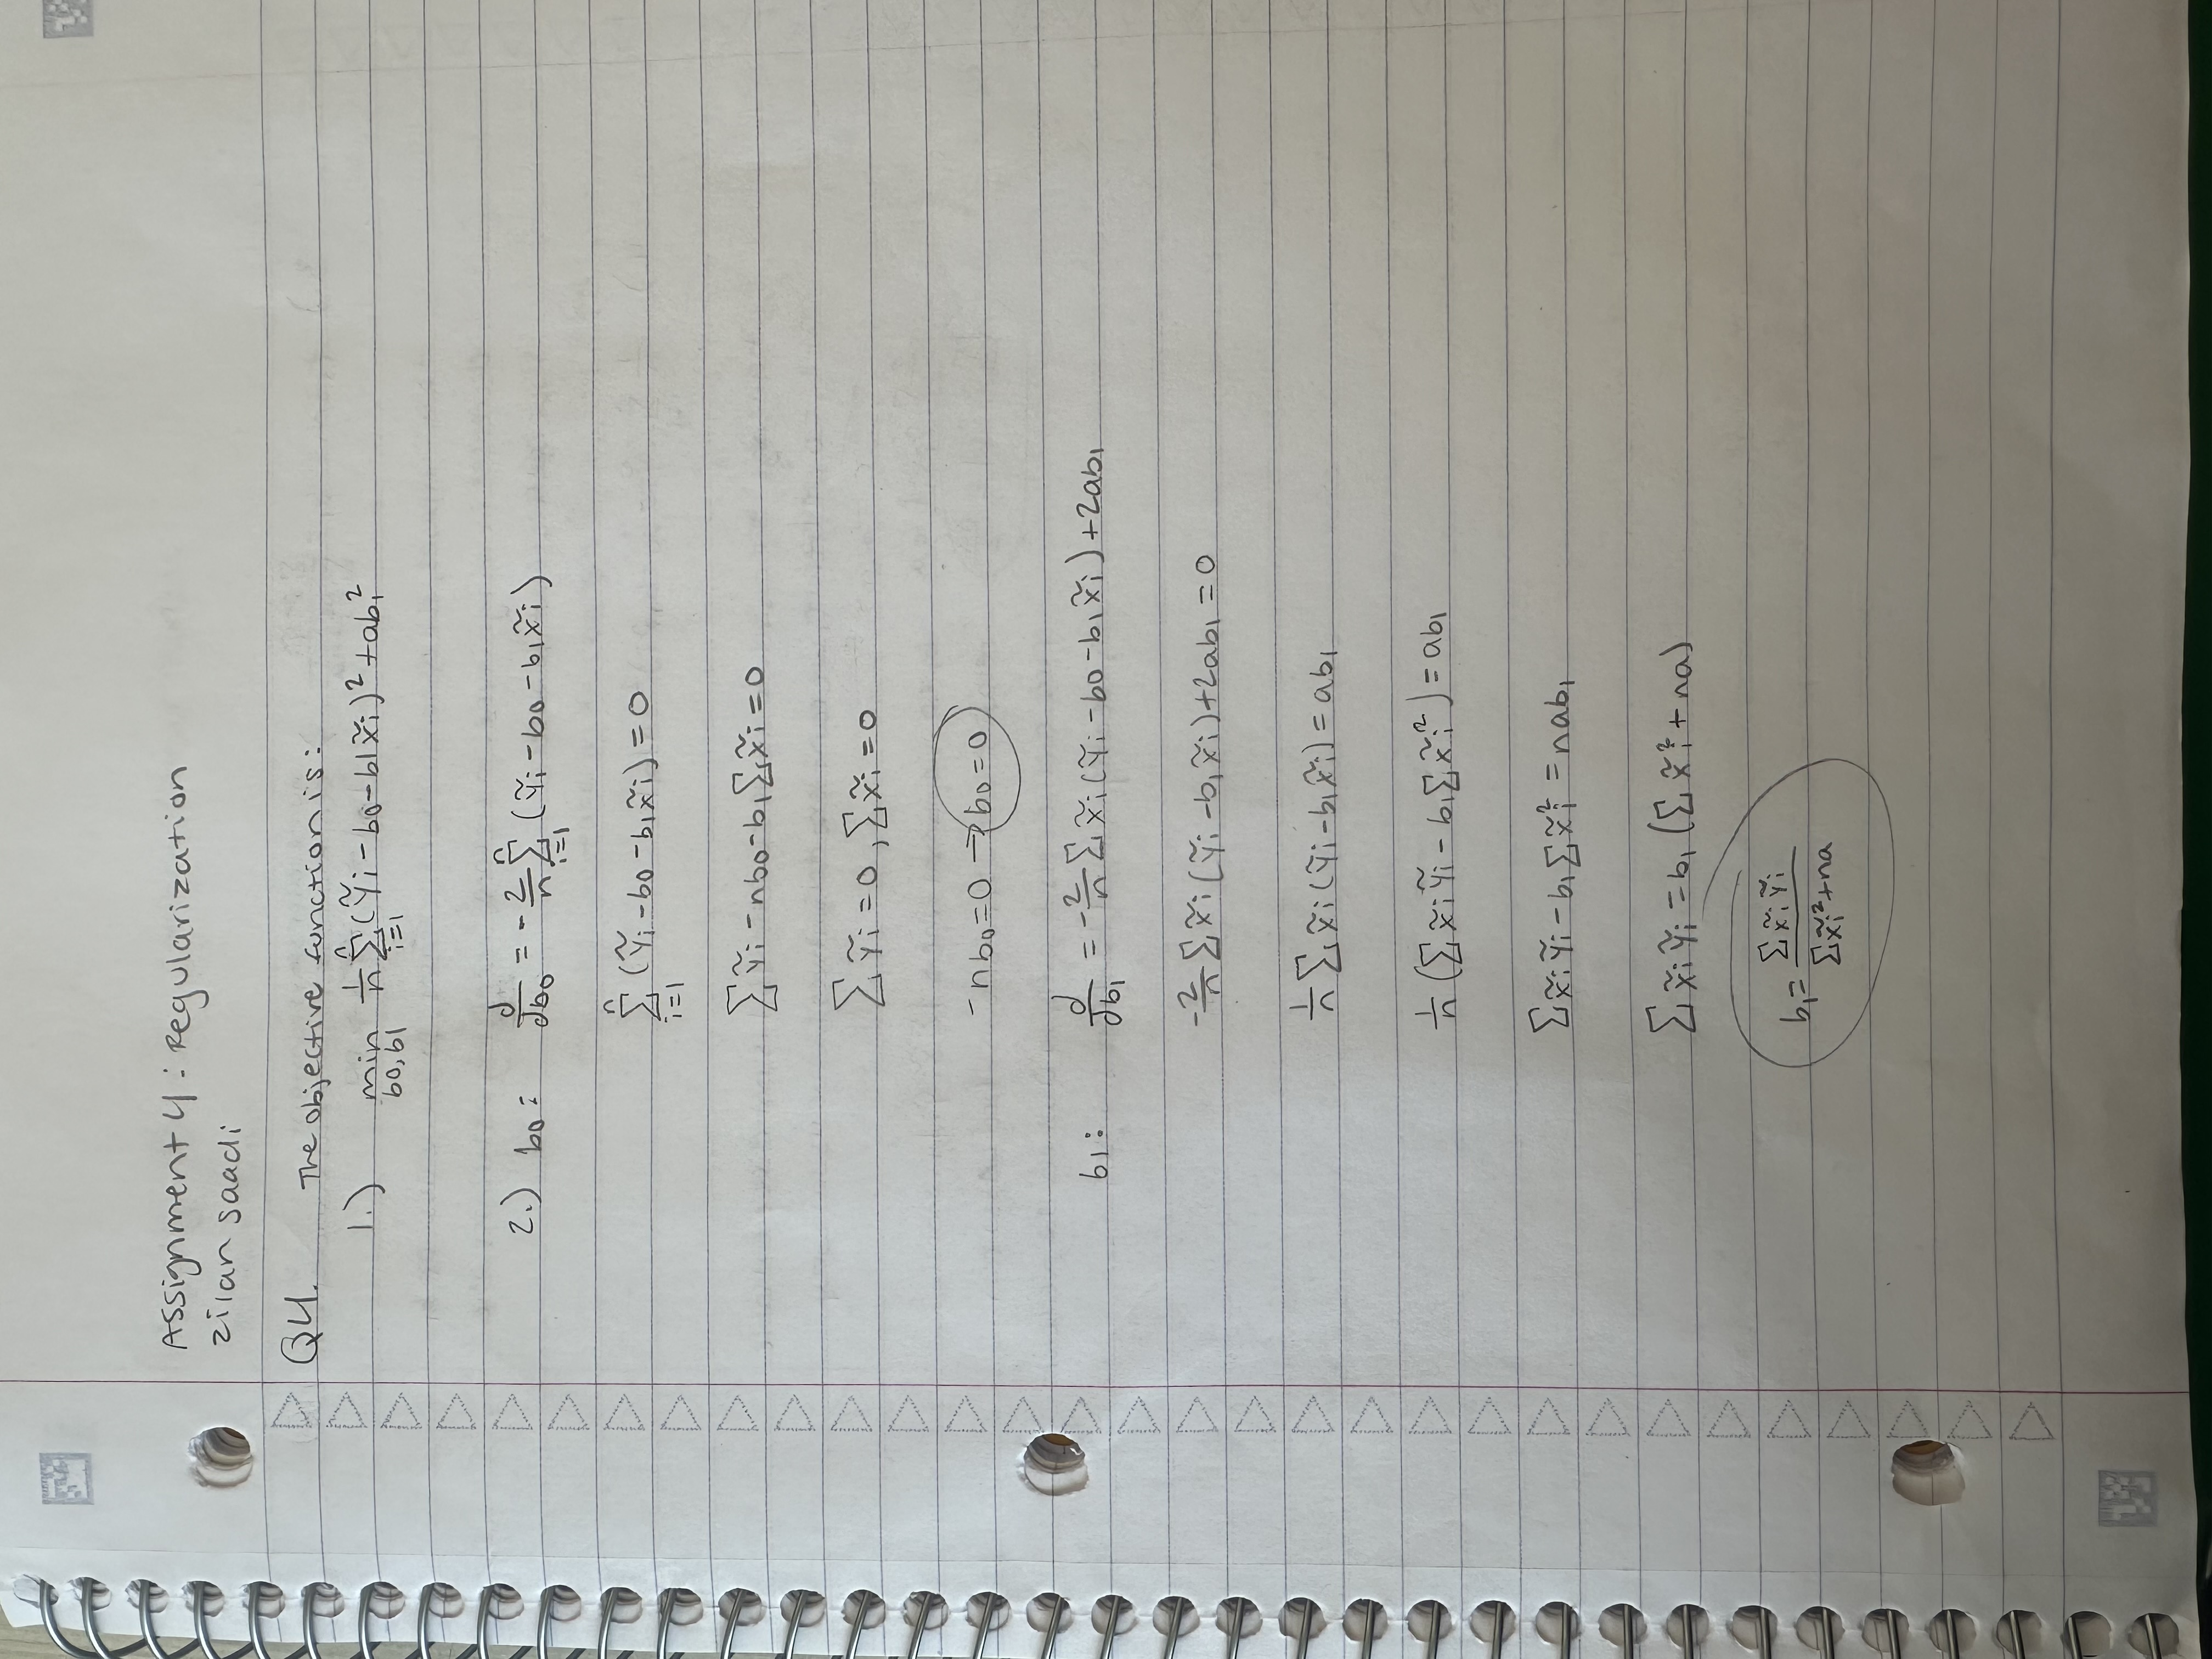

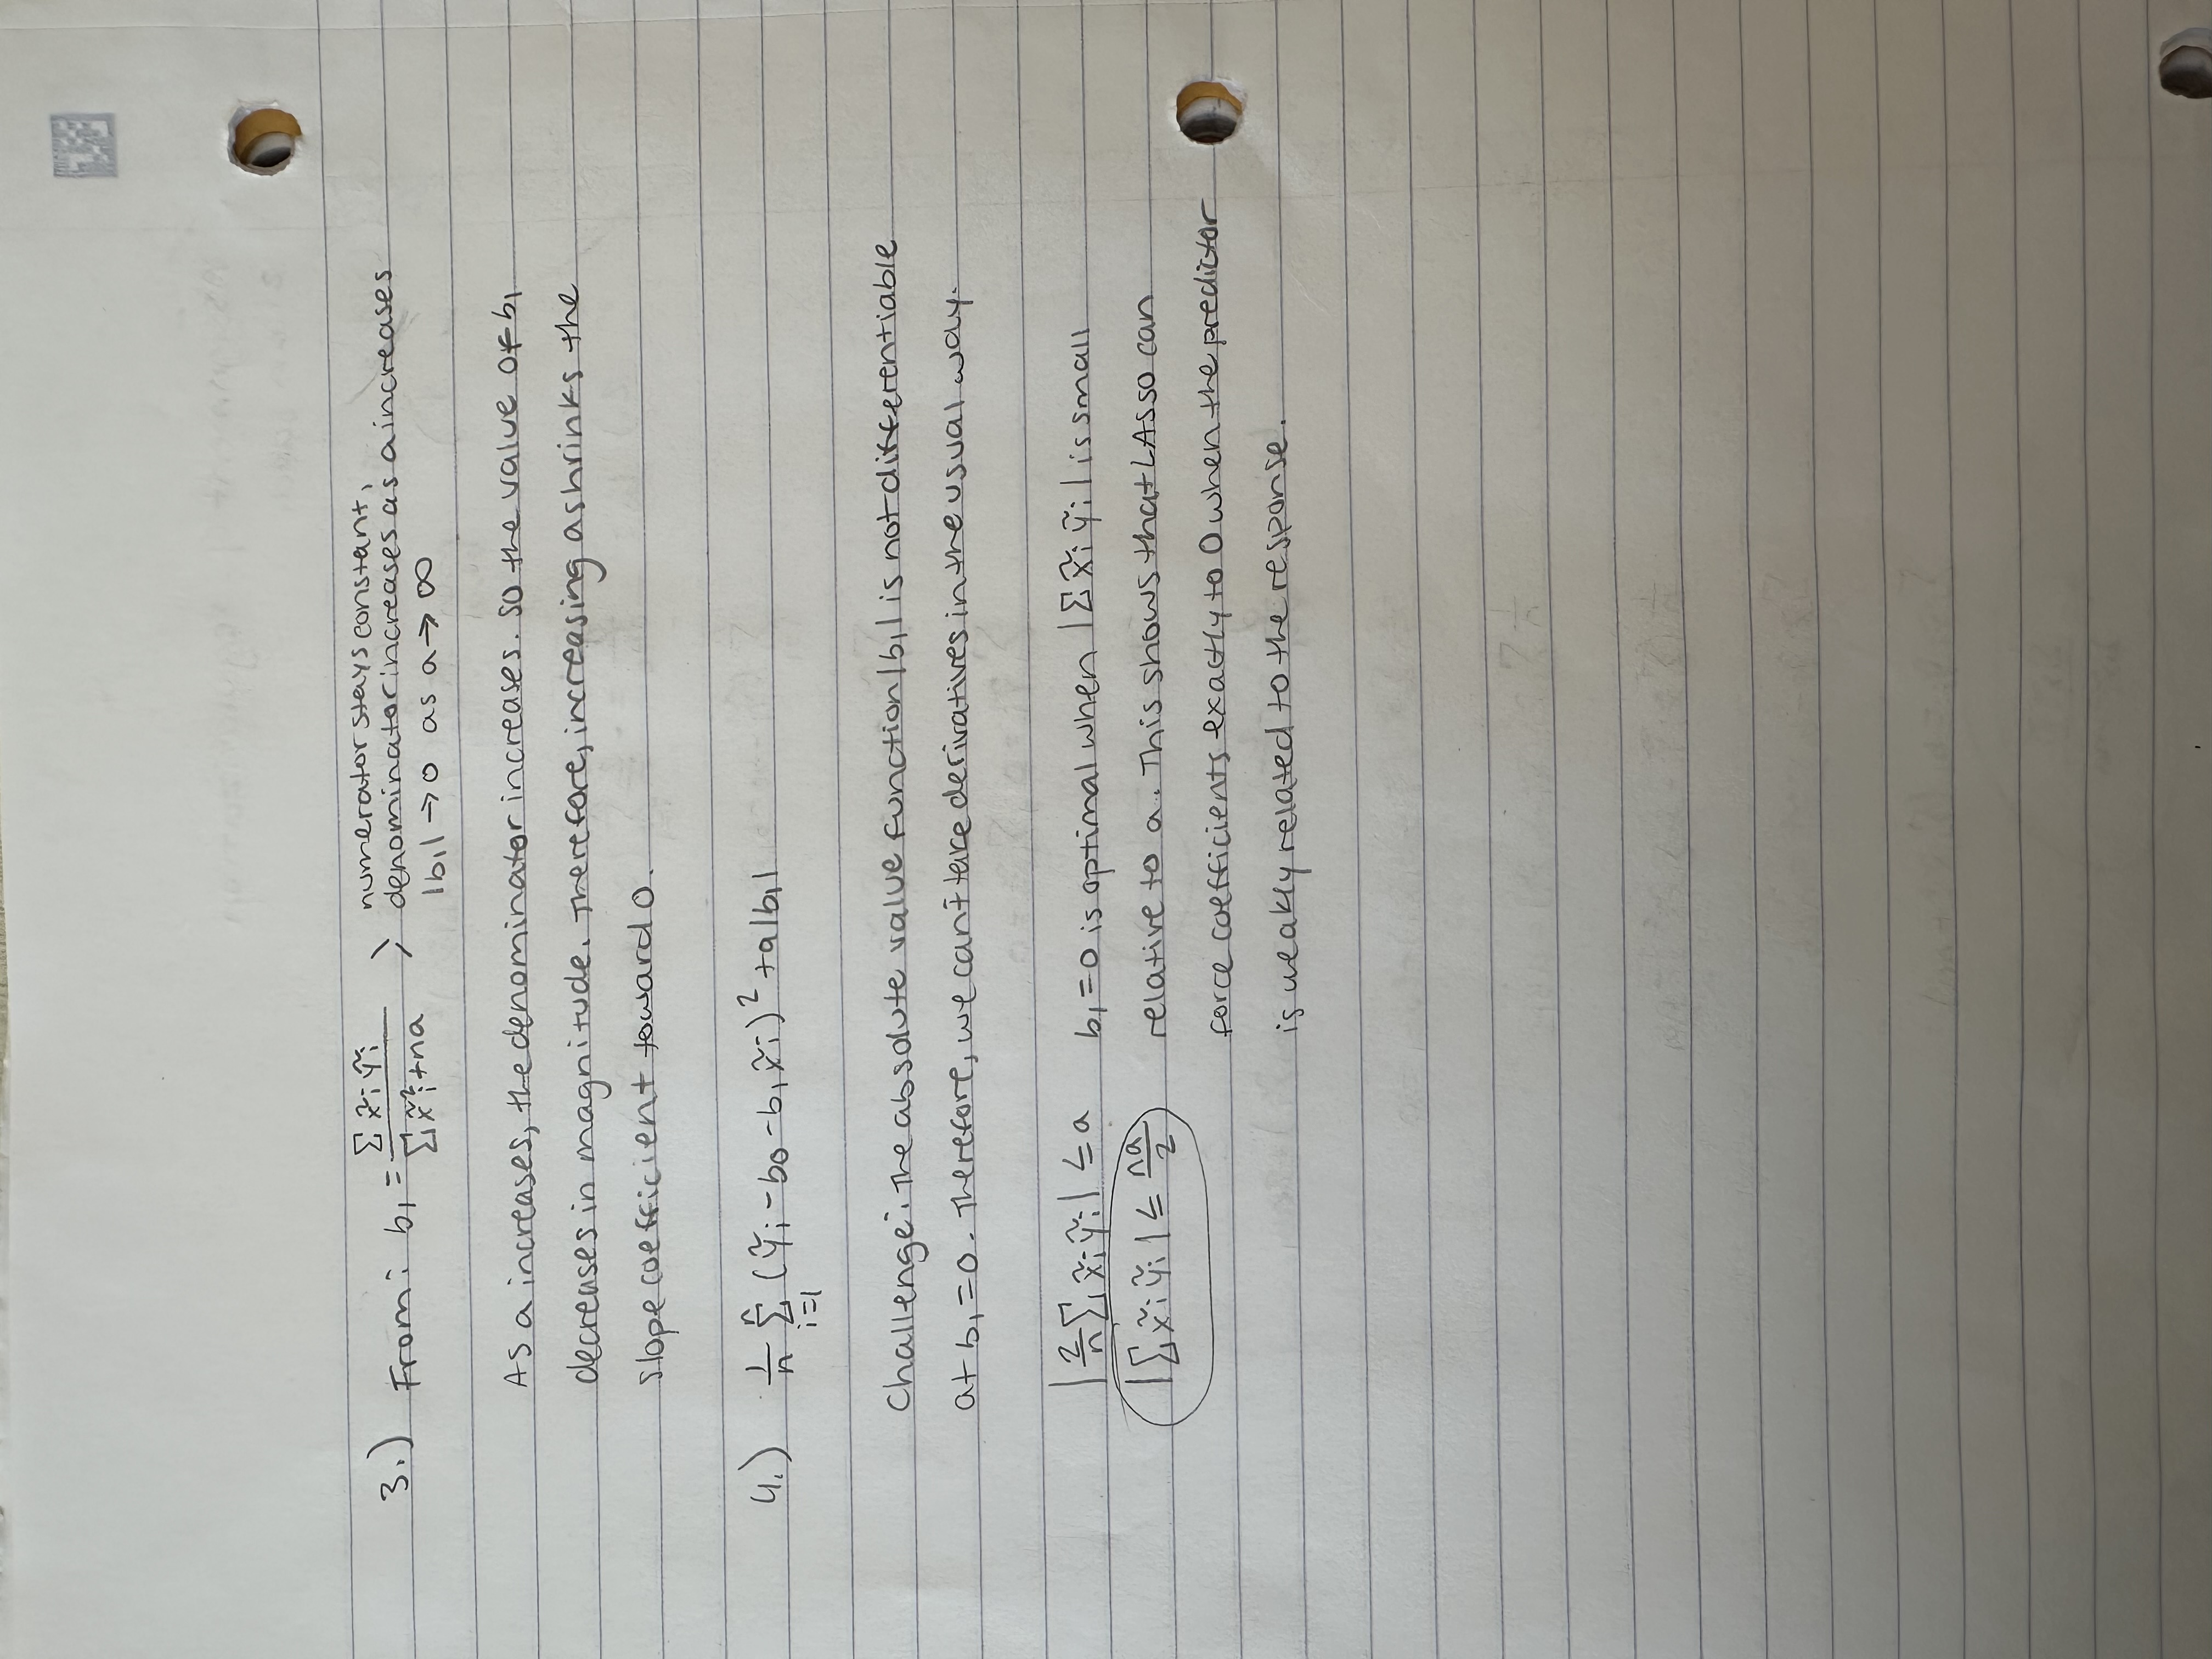